In [4]:
import numpy as np
import matplotlib.pyplot as plt
import sklearn # This is only to generate a dataset
from helperFunctions import *

# Initializing and shuffling dataset
from sklearn.datasets import make_blobs
X, t_multi = make_blobs(n_samples=[400, 400, 400, 400, 400], centers=[[0,1],[4,2],[8,1],[2,0],[6,0]], 
                  n_features=2, random_state=2024, cluster_std=[1.0, 2.0, 1.0, 0.5, 0.5])

indices = np.arange(X.shape[0])
rng = np.random.RandomState(2024)
rng.shuffle(indices)
indices[:10]

array([ 937, 1776,  868, 1282, 1396,  147,  601, 1193, 1789,  547])

In [5]:
# Splitting into train, dev and test
# train is used for training the models,
X_train = X[indices[:1000],:]
X_val = X[indices[1000:1500],:]
X_test = X[indices[1500:],:]
t_multi_train = t_multi[indices[:1000]]
t_multi_val = t_multi[indices[1000:1500]]
t_multi_test = t_multi[indices[1500:]]

Next, we will  make a second dataset with only two classes by merging the existing labels in (X,t), so that `0`, `1` and `2` become the new `0` and `3` and `4` become the new `1`. Let's call the new set (X, t2). This will be a binary set.
We now have two datasets:

- Binary set: `(X, t2)`
- Multi-class set: `(X, t_multi)`

In [6]:
t2_train = t_multi_train >= 3
t2_train = t2_train.astype('int')
t2_val = (t_multi_val >= 3).astype('int')
t2_test = (t_multi_test >= 3).astype('int')

In [ ]:
# Plotting the datasets
plt.figure(figsize=(8,6)) # You may adjust the size
plt.scatter(X_train[:, 0], X_train[:, 1], c=t_multi_train, s=10.0)
plt.title("Multi-class set")

plt.figure(figsize=(8,6))
plt.scatter(X_train[:, 0], X_train[:, 1], c=t2_train, s=10.0)
plt.title("Binary set")

Text(0.5, 1.0, 'Binary set')

# Part 1: Linear classifiers
### Linear regression

We see that even the binary set (X, t2) is far from linearly separable, and we will explore how various classifiers are able to handle this. We start with linear regression with the Mean Squared Error (MSE) loss, although it is not the most widely used approach for classification tasks: but we are interested. Implemented in linearRegression.py

In [ ]:
from linearRegression import *

#Training and results for LinRegClassifier
cl = NumpyLinRegClass()
cl.fit(X_train, t2_train, epochs=3)
print("Accuracy on the test set:", accuracy(cl.predict(X_val), t2_val))
plot_decision_regions(X_train, t2_train, cl)

NameError: name 'X_train' is not defined

As you can see, the results of the first iteration are not very impressive. We will attempt to find more optimal training values with a tuner function.

best accuracy: 0.76
optimal values for lr and number of epochs: 0.07|279


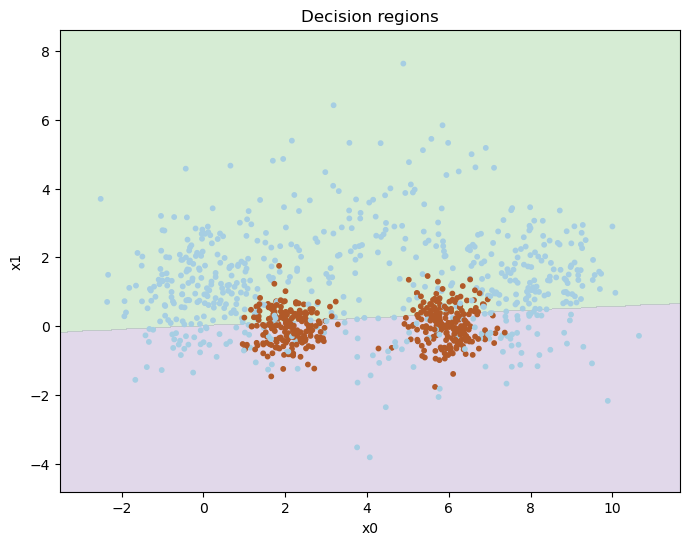

In [ ]:
tuning_values = cl_tuner(cl, X_train, t2_train, X_val, t2_val, 0.01, 0.2, 300)
print_tuning_values(tuning_values)
cl.fit(X_train, t2_train, 0.07, 279)
plot_decision_regions(X_train, t2_train, cl)

Using the tuner, we have found more optimal values for lr and number of epochs, increasing the accuracy from 0.58 to 0.76. We will try to scale the dataset to measure effects on performance and results

best accuracy: 0.784
optimal values for lr and number of epochs: 1.8|5


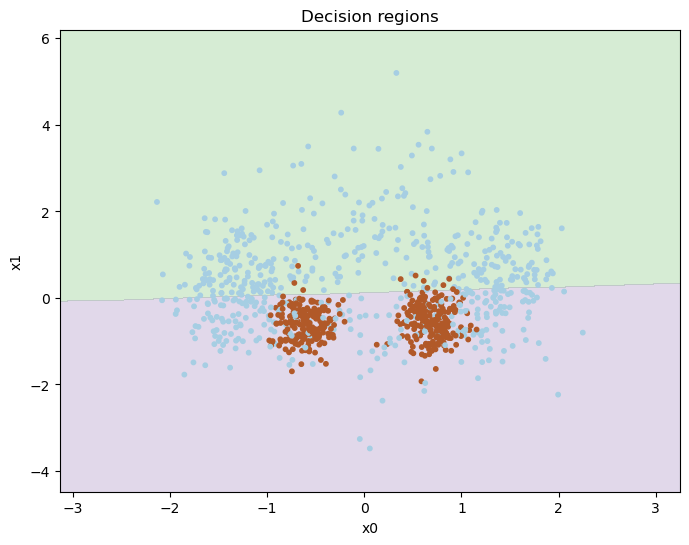

In [ ]:
'''ZScoreNormalizer scaler implemented below
x´= (x-mu)/sigma
mu = mean(x), sigma = std(x)'''

cl2 = NumpyLinRegClass()
def ZScoreNormalizer(X):
    (N,M) = X.shape #N datapoints, M feautures (1000,2)
    Xn = np.zeros((N,M))
    for i in range(M): 
        f = X[:, i] #List of all datapoints per feature
        mu = f.mean()
        sigma = f.std()
        f = (f-mu)/sigma #numpy arrays allow us to treat the whole matrix as a value
        Xn[:, i] = f #Update copy of X with normalized values, per feature
    return Xn

Xn = ZScoreNormalizer(X_train) #All features normalized between -2 and 2

tuning_values_normalized = cl_tuner(cl2, Xn, t2_train, X_val, t2_val, 0.01, 5, 50, 0.01)
print_tuning_values(tuning_values_normalized)

cl2.fit(Xn, t2_train, 1.8, 5)
plot_decision_regions(Xn, t2_train, cl2)

Scaling the data slightly increased the accuracy, as well as significantly reducing the number of steps needed, from 279 epochs to 5. For larger datasets, this can significantly improve processing cost and time.

Now we will implement a logistic regression class using logistic regression. Implemented in logisticRegression.py

Logreg-model successfully tuned. Best accuracy: 0.762 achieved with lr|tol|epochs = 0.25|0.006|18


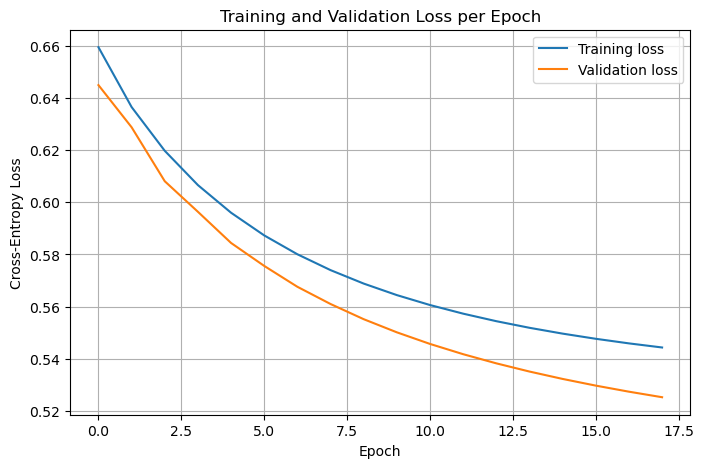

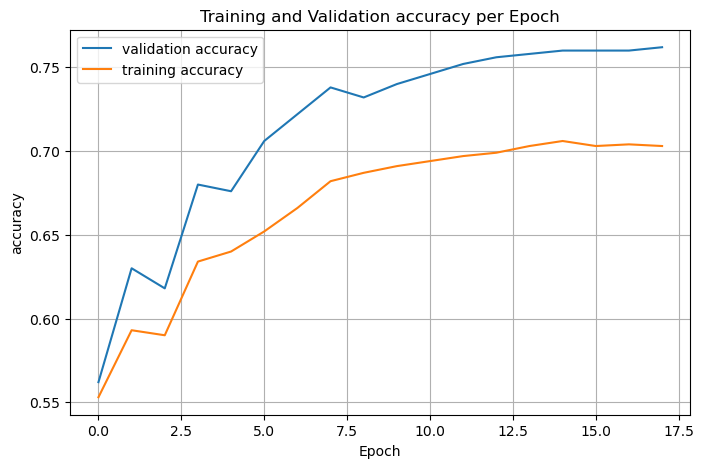

In [ ]:
from logisticRegression import *

valSet = [X_val, t2_val]
tuningValues = logRegTuner(X_train, t2_train, valSet) #best parameters: lr|tol = 0.405|0.002. Acc: 0.766
lr, tol, acc = tuningValues

# Xn = ZScoreNormalizer(X_train)
# lr2, tol2, acc2 = logRegTuner(Xn, t2_train, valSet)

cl2 = NumpyLogReg()
epochs = cl2.fit(X_train, t2_train, eta = lr, tol = tol, valSet = valSet)

history = cl2.getHistory()
plotLoss(history["trainLoss"], history["valLoss"])
plotAcc(history["trainAcc"], history["valAcc"])

My best model was trained on unscaled data for 18 epochs, using lr = 0.25, and tol = 0.006. Scaling the data interestingly worsened both the calculation time, and the best accuracy.
The curves as shown are oscillating, and non-monotonous. This could indicate that the learning rate is slightly too high, as the logistic regression algorithm seems to overshoot slightly every epoch. We can however see clearly that the oscillations decrease in intensity over time, and the graph seems to stabilize around 0.76 accuracy, which is a good score for a linear classifier on this specific problem.

## Multi-class classifiers
We turn to the task of classifying when there are more than two classes
### "One-vs-rest" with logistic regression
We will train one logistic regression classifier for each class. To predict the class of an item, we run all the binary classifiers and collect the probability score from each of them. We assign the class which ascribes the highest probability. Implemented in oneVsRest.py

Tuning commenced.
Logreg-model successfully tuned. Best accuracy: 0.932 achieved with lr|tol|epochs = 1.86|0.01|20
Tuning finished. Time elapsed: 2.3s

Tuning commenced.
Logreg-model successfully tuned. Best accuracy: 0.868 achieved with lr|tol|epochs = 0.67|0.01|19
Tuning finished. Time elapsed: 1.7s

Tuning commenced.
Logreg-model successfully tuned. Best accuracy: 0.924 achieved with lr|tol|epochs = 1.69|0.01|18
Tuning finished. Time elapsed: 2.0s

Tuning commenced.
Logreg-model successfully tuned. Best accuracy: 0.808 achieved with lr|tol|epochs = 1.25|0.002|15
Tuning finished. Time elapsed: 1.4s

Tuning commenced.
Logreg-model successfully tuned. Best accuracy: 0.816 achieved with lr|tol|epochs = 0.88|0.01|20
Tuning finished. Time elapsed: 2.0s

Model successfully tuned. Returning datasets and optimal fitting values
Model successfully trained
Accuracy:  0.748


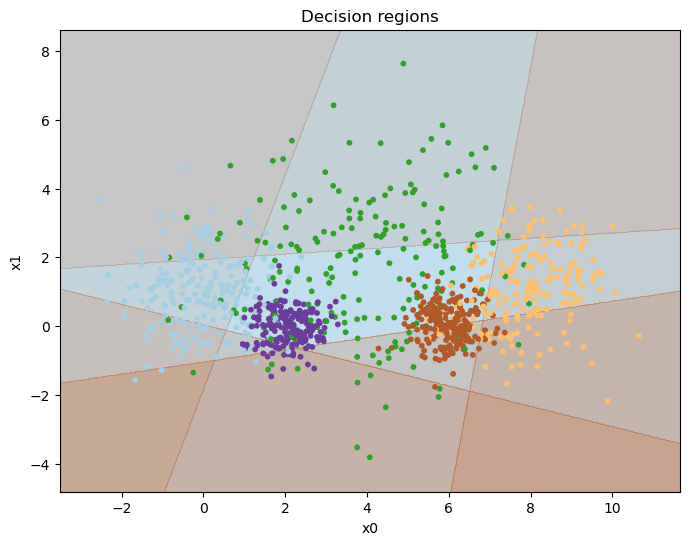

In [ ]:
from oneVsRest import *

ova = NumpyOneVsRest()
# predictedValues = ova.tune_datasets(X_train, t_multi_train, X_val, t_multi_val)

ova.fit(X_train, t_multi_train, X_val, t_multi_val)
result = ova.predict(X_train)
print("Accuracy: ", accuracy(ova.predict(X_val), t_multi_val))

liste = []
for i in range(5):
    model = ova.logregModels[i]
    liste.append(model)
plot_decision_regions(X_train, t_multi_train, liste)


Implementation of multinomial regression in logRegMultinomial.py

In [ ]:
from logRegMultinomial import *

tuningValues = multinomial_tuner(
    X_train,
    t_multi_train,
    valSet=(X_val, t_multi_val),
)

#Best model: 
cl_multinomial = NumpyMultinomial()
cl_multinomial.fitSimple(X_train, t_multi_train, tuningValues[0], tuningValues[2])
print("Best model accuracy:", accuracy(cl_multinomial.predict(X_val), t_multi_val))

Multinomial tuning commenced.
Tuning finished. Time elapsed: 2.8s
Best accuracy achieved: 0.792 with tuning values (lr|tol|epochs): 0.24|0.002|169

simple fitting completed
Best model accuracy: 0.792
